У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [85]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from pathlib import Path
from mlpeople.io.google_drive import download_file_iss
from mlpeople.io import save_df_zip_csv

raw_train_file_path = Path("./downloads/store_item_train.csv")
zip_train_file_path = Path("./data/train.csv.zip")

# download only if files does NOT exist
if not raw_train_file_path.exists():
    print("Downloading train file...")
    download_file_iss(
        '1AynEN7-ssczCsgnM8bjxRd_LJ5J8olln',
        output_path=str(raw_train_file_path)
    )
else:
    print("Train file already exists. Skipping download.")

raw_df = pd.read_csv(raw_train_file_path)

# save zip to repo if not there
if not zip_train_file_path.exists():
    print("Zipping train file...")
    save_df_zip_csv(raw_df, "data/train.csv")
else:
    print("Zipped train file already exists. Skipping zip.")

# read data from zipped file
store_item_df = pd.read_csv(zip_train_file_path)

# transform date to datetime and make it index
store_item_df['date'] = pd.to_datetime(store_item_df['date'])
store_item_df.set_index('date', inplace=True)

# show first 10 rows
store_item_df.head(10)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Train file already exists. Skipping download.
Zipped train file already exists. Skipping zip.


,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [86]:
store_item_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



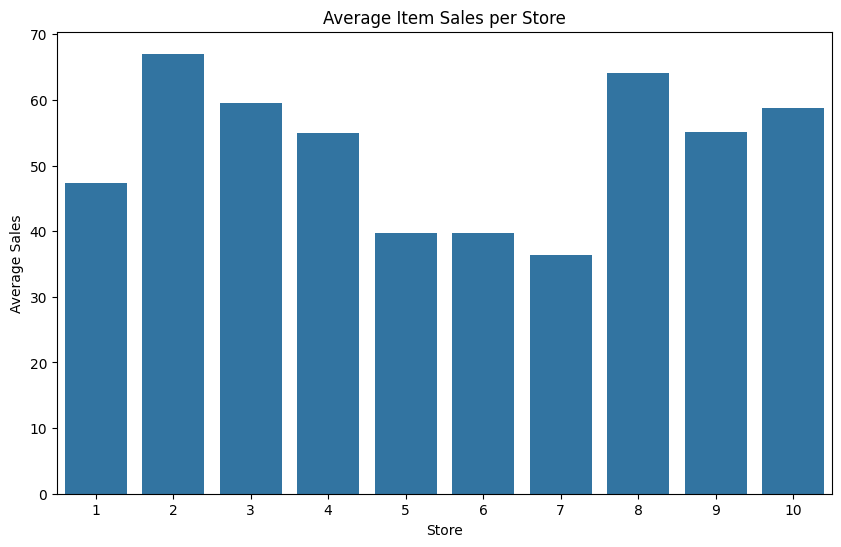

In [87]:
avg_sales_store = store_item_df.groupby('store')['sales'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=avg_sales_store, x='store', y='sales')
plt.title('Average Item Sales per Store')
plt.xlabel('Store')
plt.ylabel('Average Sales')
plt.show()

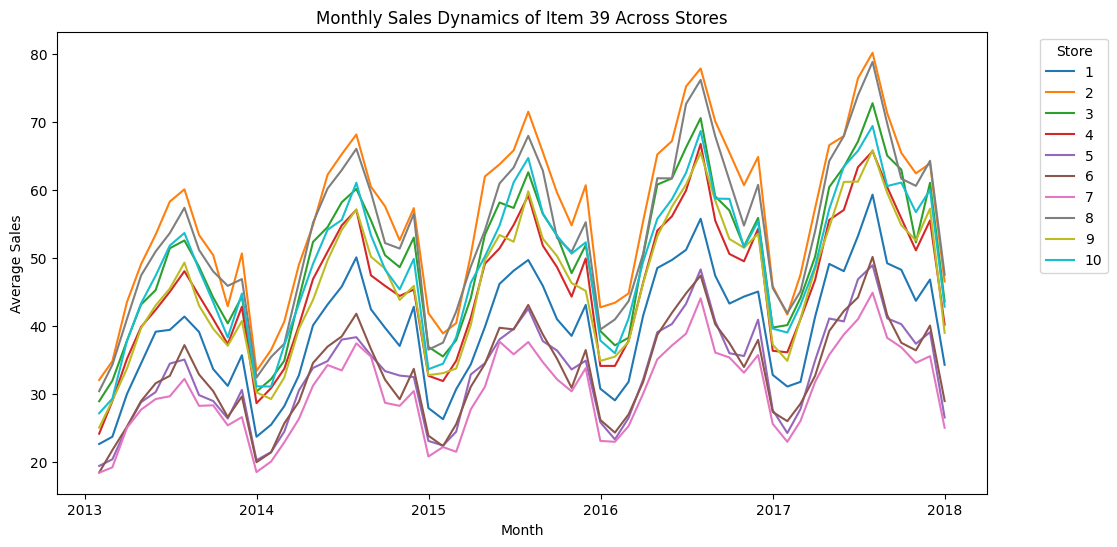

In [88]:
# Pick a random item
random_item = np.random.choice(store_item_df['item'].unique())
item_df = store_item_df[store_item_df['item'] == random_item]

# Resample per month (average sales)
item_monthly = item_df.groupby('store')['sales'].resample('ME').mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=item_monthly, x='date', y='sales', hue='store', palette='tab10')
plt.title(f'Monthly Sales Dynamics of Item {random_item} Across Stores')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.legend(title='Store', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

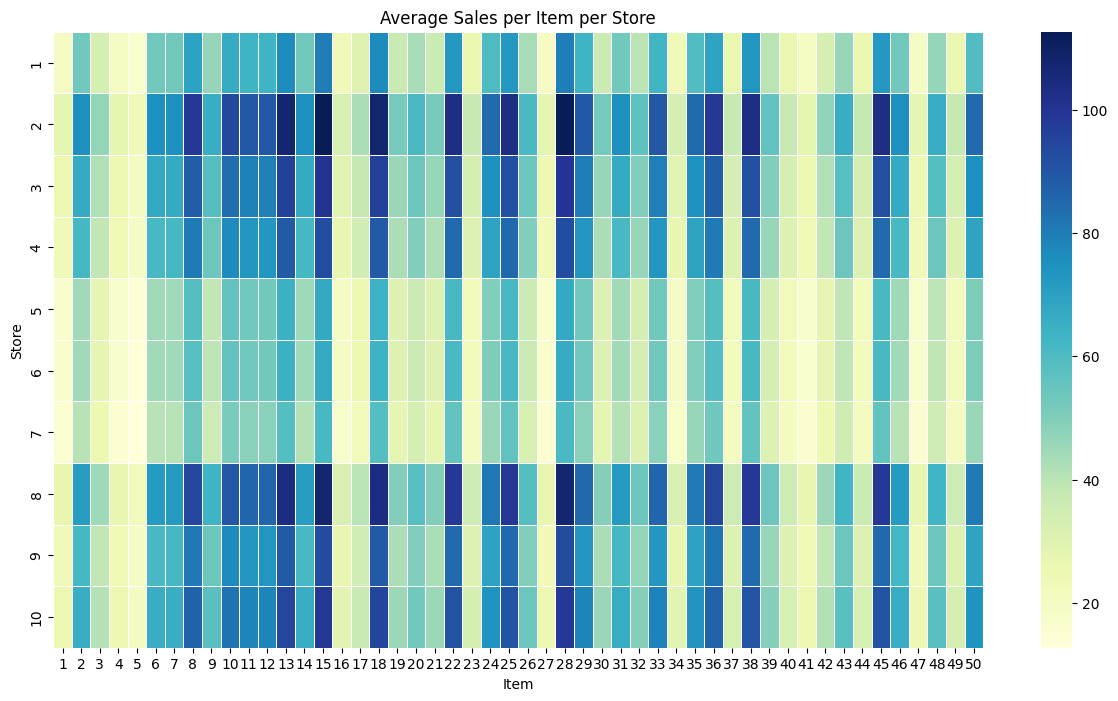

In [89]:
avg_sales_matrix = store_item_df.groupby(['store', 'item'])['sales'].mean().unstack()

plt.figure(figsize=(15,8))
sns.heatmap(avg_sales_matrix, cmap='YlGnBu', linewidths=0.5)
plt.title('Average Sales per Item per Store')
plt.xlabel('Item')
plt.ylabel('Store')
plt.show()

<span style="display: block; background-color: #f60">

 - Some stores perform better and some worse. Same for items.
 - The same items generally follow similar dynamics across all stores, but overall store performance might differ.
 - There is noticeable seasonality in sales, consistent for all stores.
 - Items that sell rarely do so in all stores, and popular items are consistently popular; no item is strong in one store and weak in another.

</span>

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

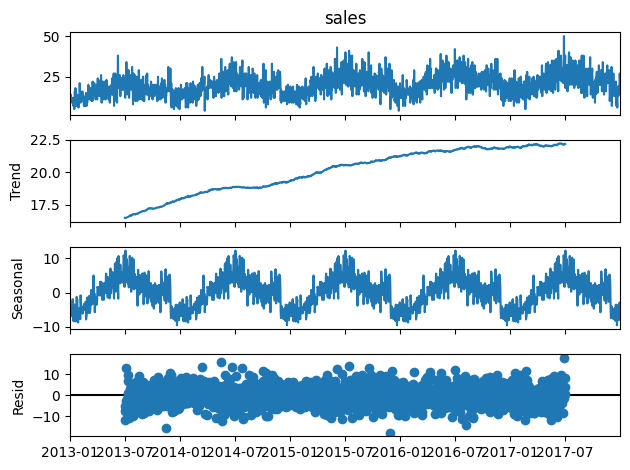

In [90]:
from statsmodels.tsa.seasonal import seasonal_decompose

store_item_1_1 = store_item_df[(store_item_df["store"] == 1) & (store_item_df["item"] == 1)]

# Decompose with a yearly seasonality (period = 365 for daily data)
decomposition_plot_multi = seasonal_decompose(store_item_1_1['sales'], model='additive', period=365)
decomposition_plot_multi.plot()
plt.show()

<span style="display: block; background-color: #f60">

 - There is a clear upward trend in sales over the years.
 - There is apparent annual seasonality in sales.
 - Grouping sales by month or week could help better understand patterns and reduce noise.
 - Aggregating data can make trends and seasonal effects more visible.
 - Resampling or smoothing the data helps prevent plots from being overfilled or hard to read.

</span>

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [91]:
# !pip install darts --quiet

In [92]:
from darts import TimeSeries

si_11_series = TimeSeries.from_dataframe(store_item_1_1, value_cols='sales')
si_11_series

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-12-27,14.0
2017-12-28,19.0
2017-12-29,15.0


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

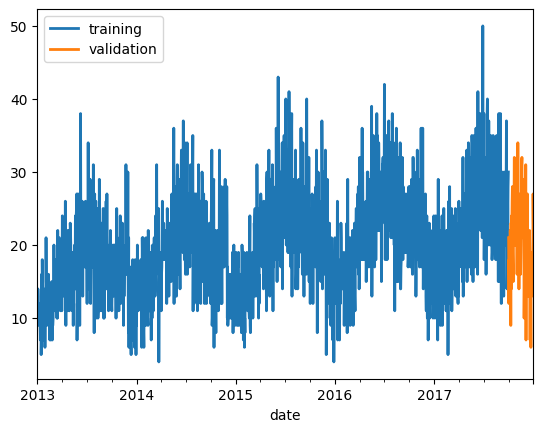

In [93]:
train_series, val_series = si_11_series.split_before(pd.Timestamp("2017-10-01"))
train_series.plot(label="training")
val_series.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

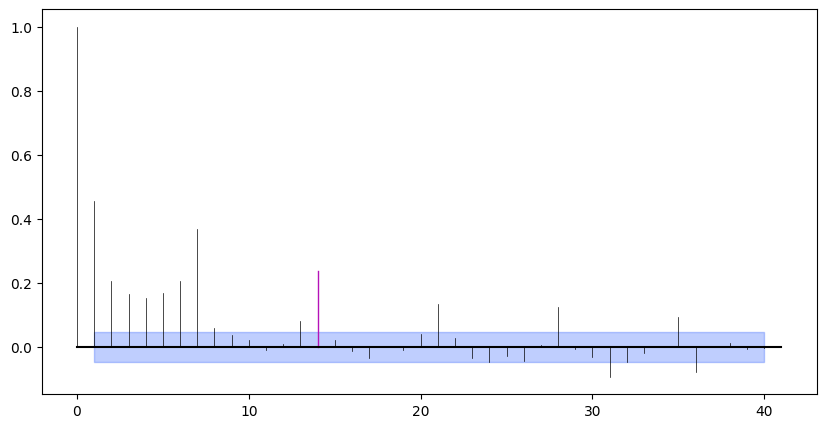

In [94]:
from darts.utils.statistics import plot_pacf, check_seasonality

plot_pacf(train_series, m=14, alpha=0.05, max_lag=40)

<span style="display: block; background-color: #f60">

 - Lags from 1 to 7 appear to be significant and likely capture short-term temporal dependencies.
 - Weekly seasonality is evident, as lags at multiples of 7 (7×N) show strong importance.
 
 </span>

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [95]:
from darts.utils.statistics import check_seasonality

periods = []

for m in range(2, 366):
    is_seasonal, period = check_seasonality(
        train_series, m=m, alpha=0.05, max_lag=365
    )
    if is_seasonal:
        periods.append(period)

print(f"Detected seasonal periods (in days): {periods}")


Detected seasonal periods (in days): [7, 14, 21, 28, 35, 42, 49, 56, 63, 70, 74, 77, 84, 91, 98, 105, 112, 119, 126, 133, 224, 231, 238, 245, 252, 259, 266, 273, 280, 287, 294, 301, 308, 315, 322, 329, 336, 343, 350, 357, 364]


<span style="display: block; background-color: #f60">

 - The series shows strong weekly seasonality (period = 7 days), confirmed by multiples of 7.
 - There are also signs of monthly (~30 days) and yearly (364 days) seasonal patterns.
 
</span>

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [96]:
val_series.shape

(92, 1, 1)

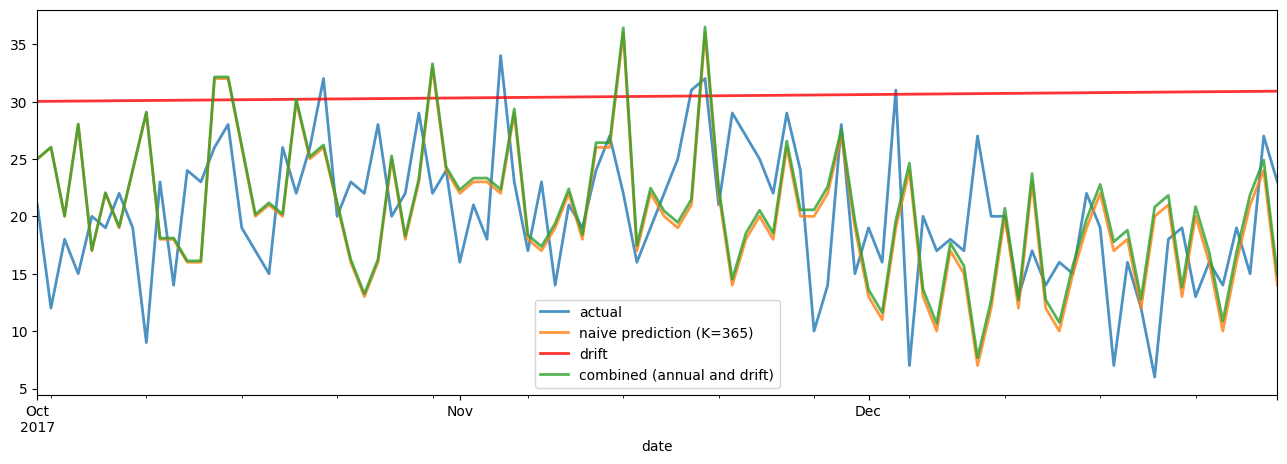

In [97]:
from darts.models import NaiveSeasonal, NaiveDrift

# annual seasonal model and forecast
year_seasonal_model = NaiveSeasonal(K=365)
year_seasonal_model.fit(train_series)
year_seasonal_forecast = year_seasonal_model.predict(92)

# drift model and forecast
drift_model = NaiveDrift()
drift_model.fit(train_series)
drift_forecast = drift_model.predict(92)

# combined forecast (both forecasts include last train value so subtract one not to double it)
dy_combined_forecast = drift_forecast + year_seasonal_forecast - train_series.last_value()

# plot all
plt.figure(figsize=(16, 5))
val_series.plot(label="actual", alpha=0.8)
year_seasonal_forecast.plot(label="naive prediction (K=365)", alpha=0.8)
drift_forecast.plot(label="drift", alpha=0.8, c="red")
dy_combined_forecast.plot(label="combined (annual and drift)", alpha=0.8)
plt.show()

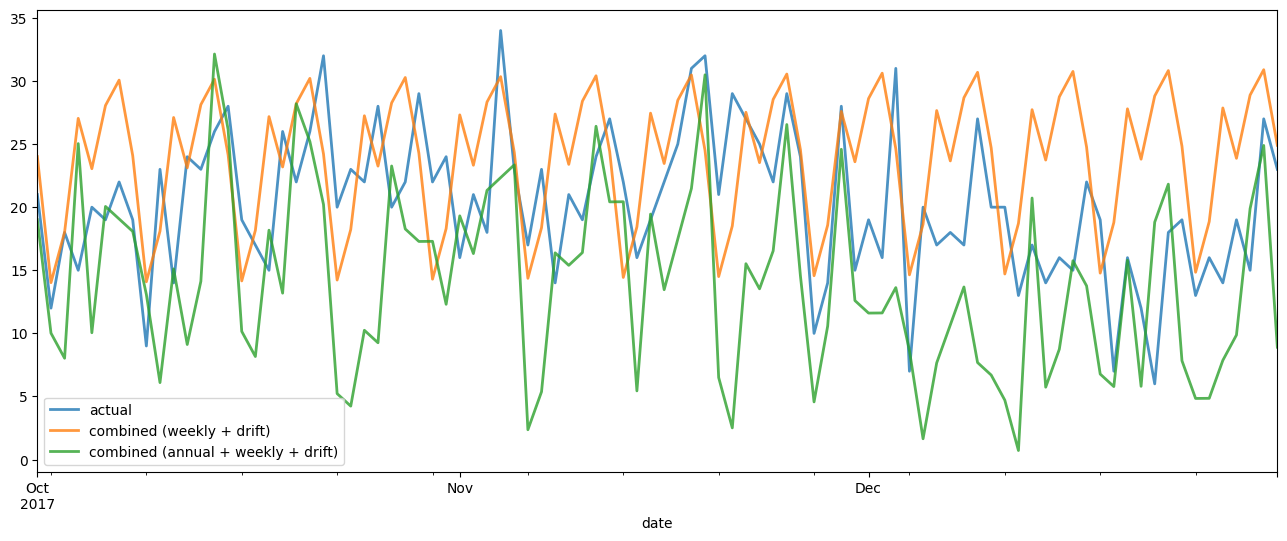

In [98]:
from darts.models import NaiveSeasonal, NaiveDrift

# weekly seasonal model and forecast
week_seasonal_model = NaiveSeasonal(K=7)
week_seasonal_model.fit(train_series)
week_seasonal_forecast = week_seasonal_model.predict(92)

# combined forecast (both forecasts include last train value so subtract one not to double it)
dw_combined_forecast = drift_forecast + week_seasonal_forecast - train_series.last_value()

# combined forecast with both seasonality (annual and weekly)
dyw_combined_forecast = dw_combined_forecast + year_seasonal_forecast - train_series.last_value()

# plot combinded forcasts with actual
plt.figure(figsize=(16, 6))
val_series.plot(label="actual", alpha=0.8)
dw_combined_forecast.plot(label="combined (weekly + drift)", alpha=0.8)
dyw_combined_forecast.plot(label="combined (annual + weekly + drift)", alpha=0.8)
plt.show()

<span style="display: block; background-color: #f60">

* Overall, naive models seem to perform not too bad
* Both seasonality options (weekly and annual) appear to perform reasonably. But it is difficult to compare results reliably just from visualization and the limited validation data. Using metrics like RMSE or MAPE would provide a clearer comparison. Increasing the validation period could also help highlight differences
* Combining both seasonalities together does not look clearly better at first glance. But again, proper metrics are needed to make a definitive assessment

</span>


9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [99]:
from darts.metrics import mape

def eval_forecast(val, forecast, name):
  mape_ = mape(val, forecast)
  print(f"Mean absolute percentage error (MAPE) for {name}: {(mape_):.2f}%.")
  return mape_

eval_forecast(val_series, dy_combined_forecast, "combined naive drift + yearly seasonal")
eval_forecast(val_series, dw_combined_forecast, "combined naive drift + weekly seasonal")
eval_forecast(val_series, dyw_combined_forecast, "combined naive drift + yearly + weekly seasonal");

Mean absolute percentage error (MAPE) for combined naive drift + yearly seasonal: 34.26%.
Mean absolute percentage error (MAPE) for combined naive drift + weekly seasonal: 39.91%.
Mean absolute percentage error (MAPE) for combined naive drift + yearly + weekly seasonal: 40.01%.


<span style="display: block; background-color: #f60">

* Now, based on the MAPE metric, we can clearly see that even for our relatively short validation period, yearly seasonality performs better than weekly or the combination of both

</span>


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [100]:
def plot_results(series, forecast, name):
  plt.figure(figsize=(12, 4))
  series.plot(label='Actual')
  forecast.plot(label=f'{name} Forecast', color='red')
  plt.legend()
  plt.show()

def fit_and_plot(model, train, val, name=None):
  if name is None:
    name = model.__class__.__name__

  model.fit(train)
  forecast = model.predict(len(val))
  eval_forecast(val, forecast, name)
  plot_results(val, forecast, name)


Mean absolute percentage error (MAPE) for XGB baseline: 25.11%.


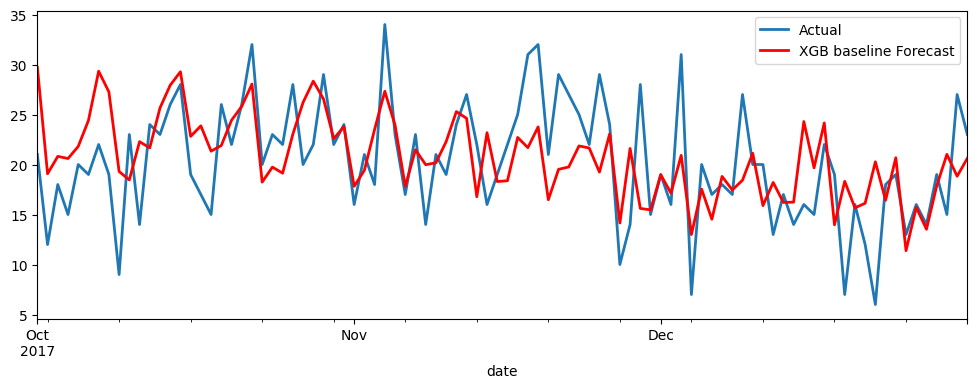

In [106]:
from darts.models import XGBModel

# build XGBoost model
xgb_model = XGBModel(
    lags=365,  # Using the last 365 observations for forecasting
)

fit_and_plot(xgb_model, train_series, val_series, name="XGB baseline")

In [166]:
# helper function for experiments with xgb covariates (feature engineering)
def fit_and_plot_xgb_cov(model, train, val, past_covariates=None, future_covariates=None, name=None):
  if name is None:
    name = model.__class__.__name__

  model.fit(train, past_covariates=past_covariates, future_covariates=future_covariates)
  forecast = model.predict(len(val), past_covariates=past_covariates, future_covariates=future_covariates, show_warnings=False)
  eval_forecast(val, forecast, name)
  plot_results(val, forecast, name)

In [167]:
from darts.utils.timeseries_generation import datetime_attribute_timeseries

full_series = train_series.append(val_series)

# create some additional datetime features
weekday = datetime_attribute_timeseries(full_series, "dayofweek")
month = datetime_attribute_timeseries(full_series, "month")
quarter = datetime_attribute_timeseries(full_series, "quarter")
dayofyear = datetime_attribute_timeseries(full_series, "dayofyear")

future_cov = weekday.stack(month).stack(quarter).stack(dayofyear)

Mean absolute percentage error (MAPE) for XGB with future covariates: 26.73%.


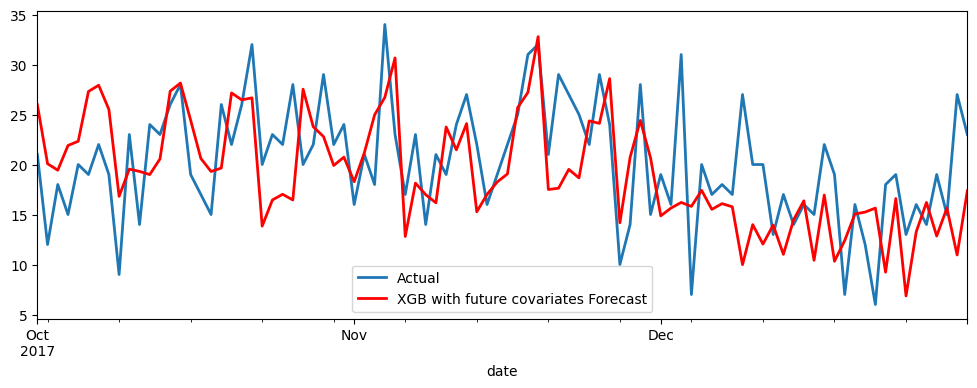

In [168]:
xgb_model_future_cov = XGBModel(
    lags=[-1, -7, -14, -365],
    lags_future_covariates=[-1],
)

fit_and_plot_xgb_cov(xgb_model_future_cov, train_series, val_series, future_covariates=future_cov, name="XGB with future covariates")

Mean absolute percentage error (MAPE) for XGB with future cyclical covariates: 23.85%.


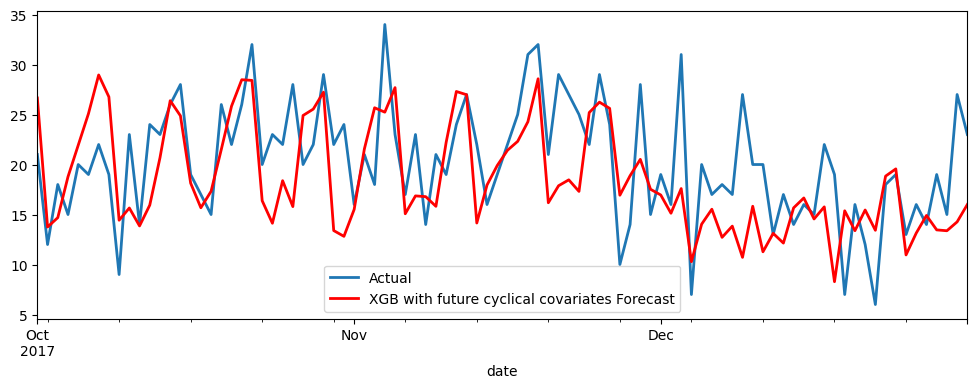

In [173]:
# experiment with cyclical encoding
def cyclical_encode(dates, period, value_fn):
    values = value_fn(dates)
    sin = np.sin(2 * np.pi * values / period)
    cos = np.cos(2 * np.pi * values / period)
    return sin, cos

full_series = train_series.append(val_series)
dates = full_series.time_index

wd_sin, wd_cos = cyclical_encode(dates, 7, lambda d: d.dayofweek)

m_sin, m_cos = cyclical_encode(dates, 12, lambda d: d.month)

dy_sin, dy_cos = cyclical_encode(dates, 365, lambda d: d.dayofyear)

cov_cycl_df = pd.DataFrame({
    "wd_sin": wd_sin,
    "wd_cos": wd_cos,
    "m_sin": m_sin,
    "m_cos": m_cos,
    "dy_sin": dy_sin,
    "dy_cos": dy_cos,
}, index=dates)

future_cycl_cov = TimeSeries.from_dataframe(cov_cycl_df)


model_future_cov_cycl = XGBModel(
    lags=[-1, -7, -14, -28, -365],
    lags_future_covariates=[-1]
)

fit_and_plot_xgb_cov(model_future_cov_cycl, train_series, val_series, future_covariates=future_cycl_cov, name="XGB with future cyclical covariates")

<span style="display: block; background-color: #f60">

* Even without precise hyperparameter tuning, the Darts XGBModel performs significantly better than naive models
* Adding additional datetime features with `past_covariates` or `future_covariates` such as weekday and month actually worsens the validation performance
* Adding additional datetime features **cyclically encoded** with `past_covariates` or `future_covariates` such as weekday and month improves the performance slightly

</span>


11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

Mean absolute percentage error (MAPE) for ExponentialSmoothing - 365 (yearly) seasonality: 30.54%.


/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


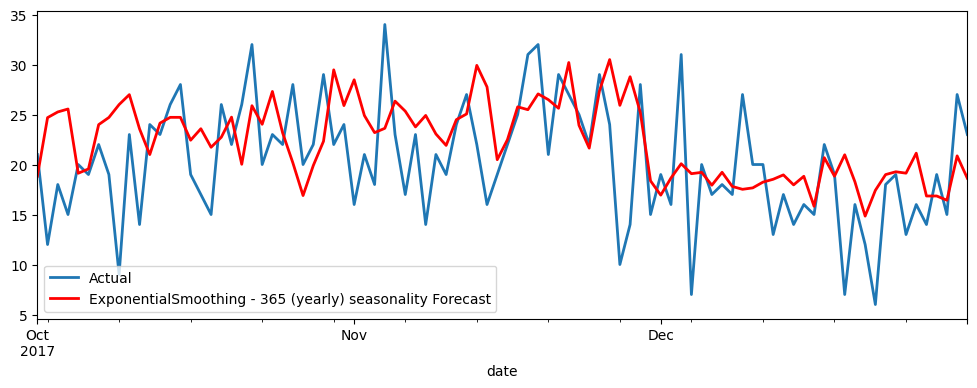

In [17]:
from darts.models import ExponentialSmoothing

exps_model = ExponentialSmoothing(seasonal_periods=365)
fit_and_plot(exps_model, train_series, val_series, name="ExponentialSmoothing - 365 (yearly) seasonality")

Mean absolute percentage error (MAPE) for ExponentialSmoothing - 7 (weekly) seasonality: 39.01%.


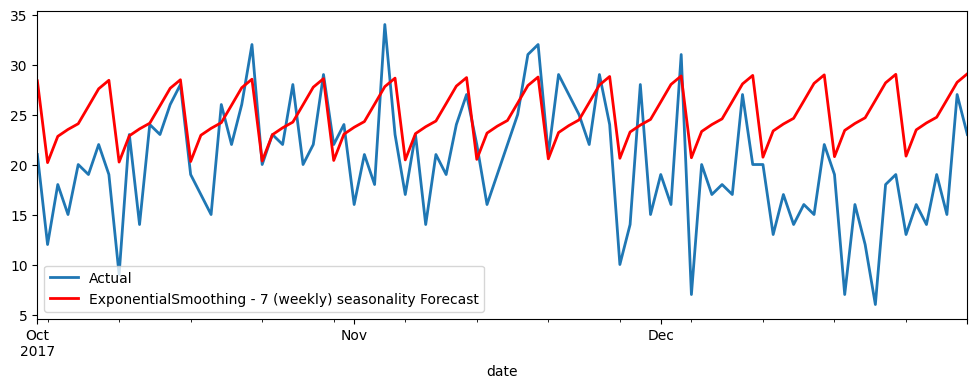

In [18]:
exps_model = ExponentialSmoothing(seasonal_periods=7)
fit_and_plot(exps_model, train_series, val_series, name="ExponentialSmoothing - 7 (weekly) seasonality")

<span style="display: block; background-color: #f60">

* Based on the warning during model fitting, yearly seasonality appears to be difficult for ExponentialSmoothing to handle, but it still achieves a decent MAPE of 30.54%
* With weekly seasonality, the result is worse (MAPE = 39.01%), performing even below the naive models

</span>


12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

Mean absolute percentage error (MAPE) for ARIMA: 38.79%.


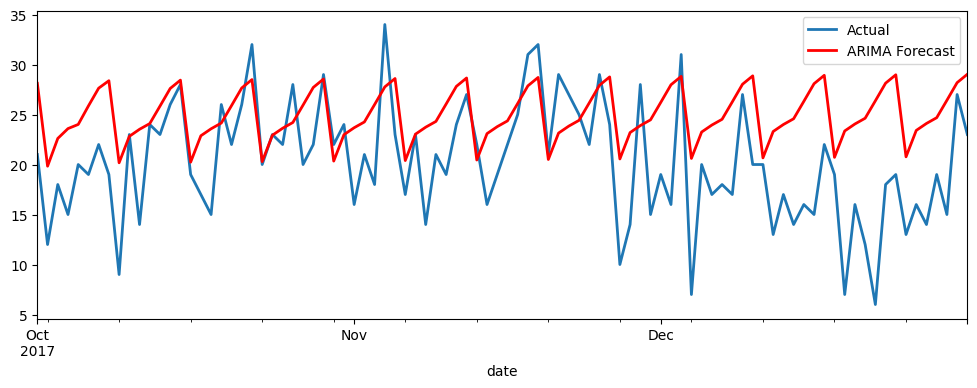

In [19]:
from darts.models import ARIMA

arima_model = ARIMA(p=2, d=1, q=1, seasonal_order=(1, 1, 1, 7))

fit_and_plot(arima_model, train_series, val_series)

<span style="display: block; background-color: #f60">

* With parameters `p=2, d=1, q=1, seasonal_order=(1, 1, 1, 7)`, ARIMA performs poorly and worse than the naive models
* Trying other parameters and hyperparameter tuning either leads to very long fitting times, warnings during model fitting, or both, indicating that ARIMA is likely mathematically inappropriate for this time series

</span>


13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [20]:
# !pip install statsforecast --quiet

Mean absolute percentage error (MAPE) for AutoARIMA: 35.55%.


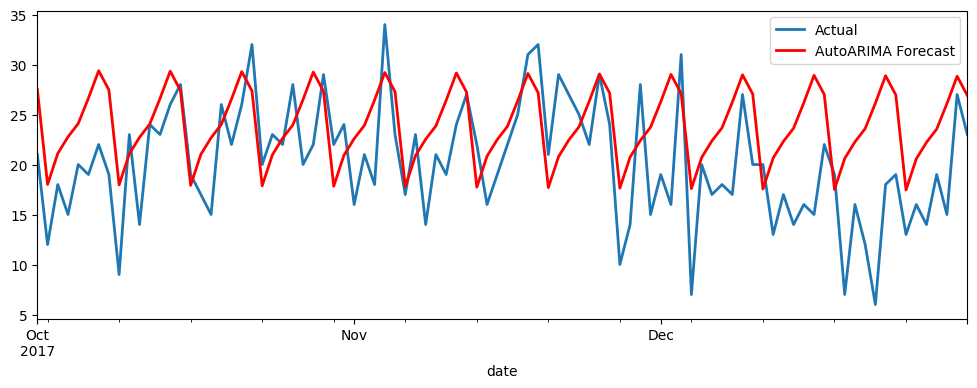

In [21]:
from darts.models import AutoARIMA

automarima_model = AutoARIMA(
    start_p=1, # capture lag 1, 2, 3, ...
    max_p=3,
    start_q=1,
    max_q=3,
    d=1,

    start_P=1, # capture lag 7, 14, 21, ...
    max_P=2,
    start_Q=1,
    max_Q=2,
    D=1,

    season_length=7,  # weekly
    stepwise=True,
    approximation=False
)

fit_and_plot(automarima_model, train_series, val_series)

<span style="display: block; background-color: #f60">

* With some hyperparameter tuning, AutoARIMA produces results close to the naive model
* The main issue is that AutoARIMA alone can hardly capture the yearly seasonality
* Combining AutoARIMA with NaiveSeasonal may be a reasonable approach

</span>


Mean absolute percentage error (MAPE) for combined auto ARIMA + yearly seasonal: 37.98%.


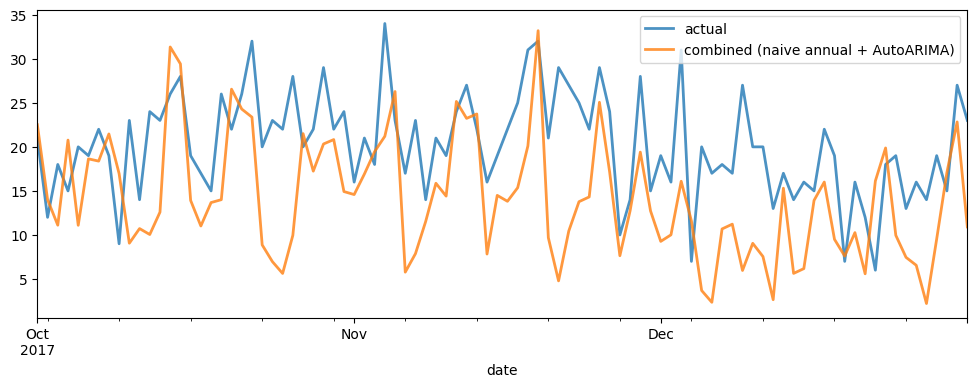

In [22]:
automarima_forecast = automarima_model.predict(len(val_series))

# combined forecast (both forecasts include last train value so subtract one not to double it)
ay_combined_forecast = automarima_forecast + year_seasonal_forecast - train_series.last_value()

eval_forecast(val_series, ay_combined_forecast, "combined auto ARIMA + yearly seasonal")

# plot combinded forcasts with actual
plt.figure(figsize=(12, 4))
val_series.plot(label="actual", alpha=0.8)
# automarima_forecast.plot(label="AutoARIMA", alpha=0.8)
ay_combined_forecast.plot(label="combined (naive annual + AutoARIMA)", alpha=0.8)
# year_seasonal_forecast.plot(label="annual", alpha=0.8)
plt.show()

<span style="display: block; background-color: #f60">

* Combining AutoARIMA with NaiveSeasonal did not imporve prediction results

</span>


14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [23]:
# !pip install "darts[notorch]" --quiet

11:23:07 - cmdstanpy - INFO - Chain [1] start processing
11:23:07 - cmdstanpy - INFO - Chain [1] done processing


Mean absolute percentage error (MAPE) for Prophet: 23.78%.


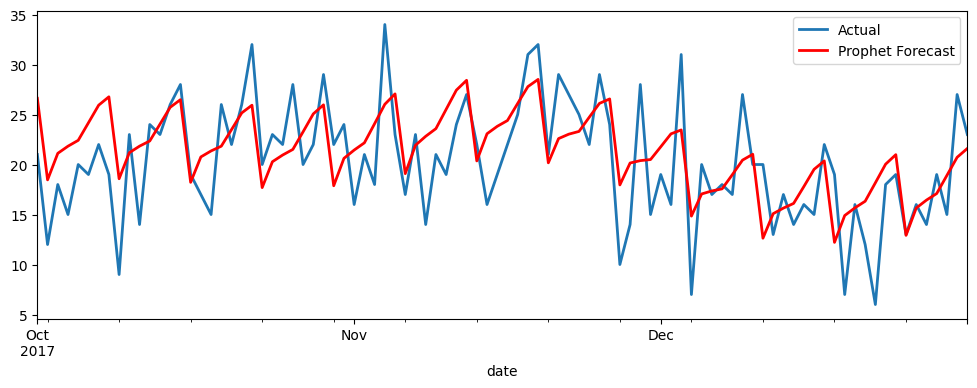

In [24]:
from darts.models import Prophet

prophet_model = Prophet()

fit_and_plot(prophet_model, train_series, val_series)

11:23:07 - cmdstanpy - INFO - Chain [1] start processing
11:23:08 - cmdstanpy - INFO - Chain [1] done processing


Mean absolute percentage error (MAPE) for Prophet Tuned: 22.69%.


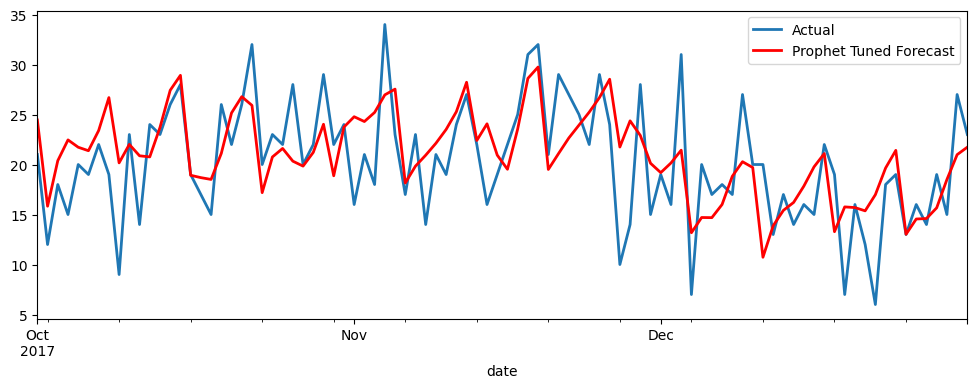

In [ ]:
from darts.models import Prophet

prophet_tuned_model = Prophet(
    # Controls flexibility of trend changes. Higher value = more flexible trend (can overfit), lower value = smoother trend (more conservative).
    changepoint_prior_scale=0.3,

    # Controls how strongly seasonal patterns are allowed to influence the model. Higher value = stronger/more flexible seasonality fitting
    seasonality_prior_scale=30,

    # Strength/complexity of yearly seasonality component. Higher value allows more complex yearly seasonal patterns.
    yearly_seasonality=90,

    # Strength/complexity of weekly seasonality component. Higher value = more flexible weekly pattern fitting.
    weekly_seasonality=20,

    # Whether to include daily seasonality. False is correct for daily sales data - there is no hours data
    daily_seasonality=False,
)

fit_and_plot(prophet_tuned_model, train_series, val_series, name="Prophet Tuned")

<span style="display: block; background-color: #f60">

* Even without hyperparameter tuning, the Prophet model performs well and already outperforms the previous models
* With hyperparameter tuning, the results were further improved

</span>


15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [26]:
# !pip install "darts[torch]" --quiet

In [27]:
train_series = train_series.astype("float32")
val_series = val_series.astype("float32")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(tree

Epoch 299: 100%|██████████| 54/54 [00:00<00:00, 190.42it/s, train_loss=27.70]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 54/54 [00:00<00:00, 189.90it/s, train_loss=27.70]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 47.57it/s]
Mean absolute percentage error (MAPE) for RNNModel: 34.34%.


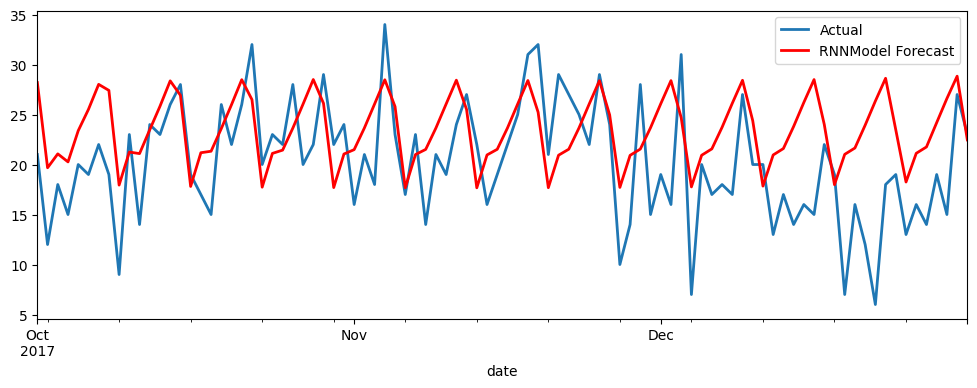

In [30]:
from darts.models import RNNModel

rnn_model = RNNModel(model='LSTM', input_chunk_length=12, n_epochs=300, random_state=42)

fit_and_plot(rnn_model, train_series, val_series)

<span style="display: block; background-color: #f60">

* The RNN model does not appear to capture yearly seasonality effectively with the used during experiment hyperparameters
* Overall, the performance is average: slightly better than naive models, but significantly worse than the best-performing XGB and Prophet models
* Additional hyperparameters tuning and increasing epochs amount might be useful here

</span>


16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [36]:
import logging

logger = logging.getLogger('cmdstanpy')
logger.addHandler(logging.NullHandler())
logger.propagate = False
logger.setLevel(logging.WARNING)

hfc_params = {
    "series": si_11_series,
    "start": pd.Timestamp("2015-01-01"),
    "forecast_horizon": 90,
    "verbose": False,
}

historical_fcast = prophet_model.historical_forecasts(last_points_only=True, **hfc_params)

MAPE = 21.04%


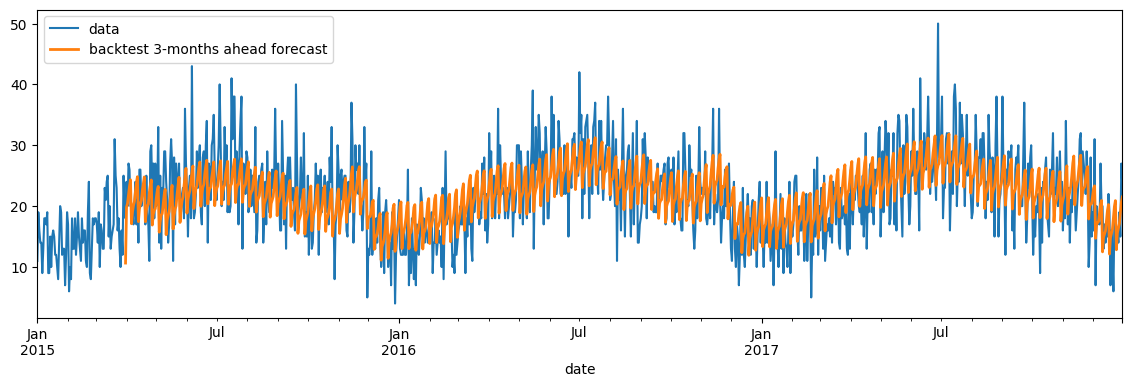

In [45]:
print(f"MAPE = {mape(si_11_series, historical_fcast):.2f}%")

plt.figure(figsize=(14, 4))
si_11_series.to_series().loc["2015-01-01" :].plot(label="data")
historical_fcast.plot(label="backtest 3-months ahead forecast")
plt.show()

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

In [174]:
store_item_df = store_item_df.reset_index()

In [175]:
from darts import TimeSeries

series_list = []
series_meta = []

# create separate timeseries for each store/item combination
for (store, item), df in store_item_df.groupby(["store", "item"]):

    df = df.sort_values("date")

    ts = TimeSeries.from_dataframe(
        df,
        time_col="date",
        value_cols="sales",
        fill_missing_dates=True,
        freq="D"   # daily data
    )

    series_list.append(ts)
    series_meta.append((store, item)) # save meta for future forecast mapping

In [180]:
from darts.models import XGBModel

xgb_model_base = XGBModel(
    lags=365,
)

# smoke test - train one xgb model for 1 store and 10 items (10 timeseries)
xgb_model_base.fit(series=series_list[:10])

XGBModel(lags=365, lags_past_covariates=None, lags_future_covariates=None, output_chunk_length=1, output_chunk_shift=0, add_encoders=None, likelihood=None, quantiles=None, random_state=None, multi_models=True, use_static_covariates=True)

In [181]:
# predict for the same 10 timeseries
xgb_base_forecast_list = xgb_model_base.predict(n=365, series=series_list[:10])

In [182]:
# attach predictions back to store/item
xgb_base_forecast_map = {}

for meta, fc in zip(series_meta, xgb_base_forecast_list):
    store, item = meta
    xgb_base_forecast_map[(store, item)] = fc

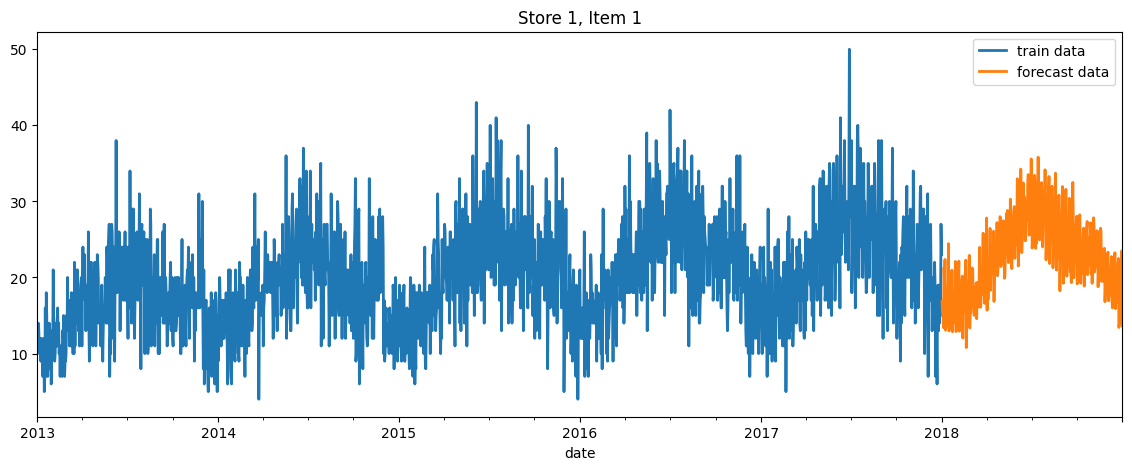

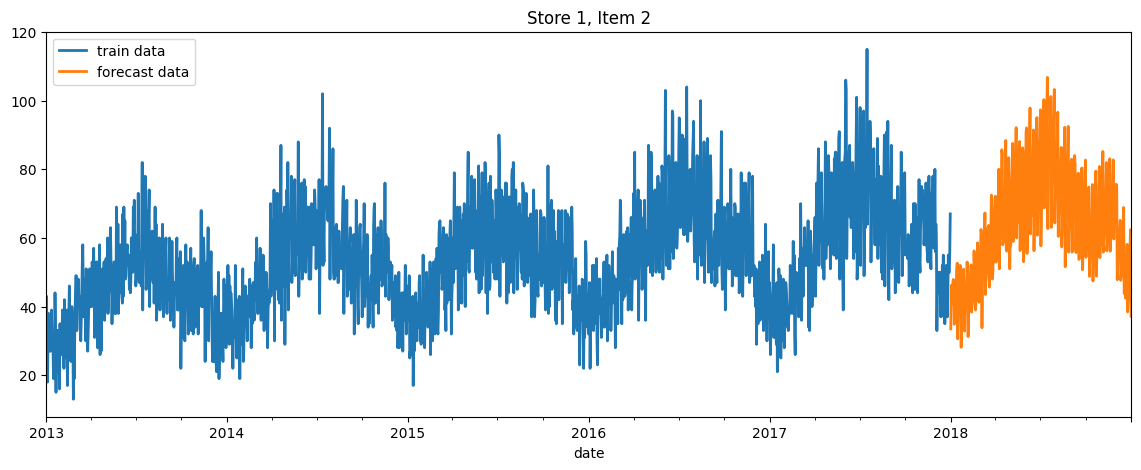

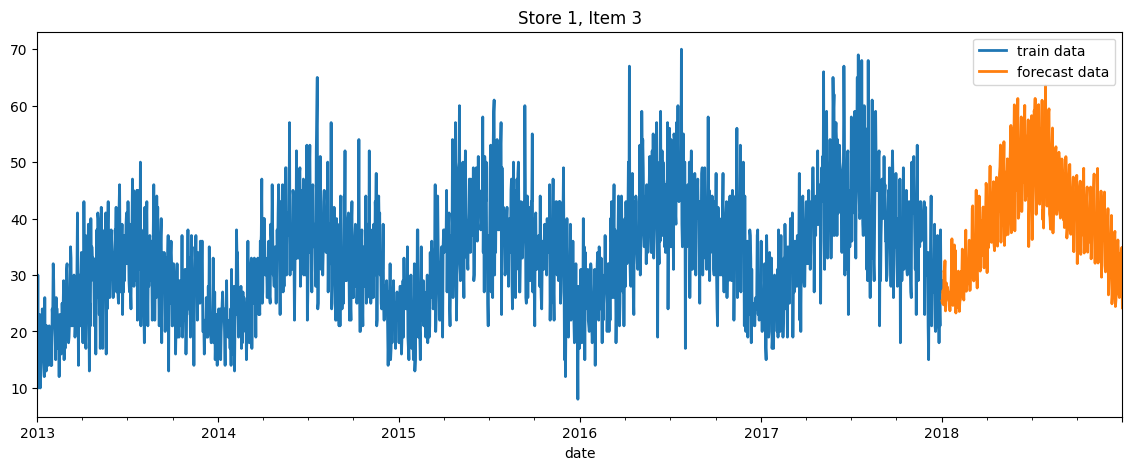

In [183]:
# plot first 3 examples
for i in range(3):
    store, item = series_meta[i]

    plt.figure(figsize=(14, 5))

    series_list[i].plot(label="train data")
    xgb_base_forecast_map[(store, item)].plot(label="forecast data")

    plt.title(f"Store {store}, Item {item}")
    plt.legend()
    plt.show()

<span style="display: block; background-color: #f60">

* Prophet, ARIMA, and Exponential Smoothing are single-series models and would require training 500 separate models
* XGB, LightGBM, and neural models in Darts support global learning and can be trained as one model on all series
* One global model learns shared seasonality and behavior across stores and items, dramatically improving performance and scalability
* For this task, the correct approach seems to be traing **one global model** (e.g., XGBModel, RNNModel) using calendar features as future covariates and **store/item identifiers as static covariates**

</span>
